# IS 4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [3]:
# Import data from the AdviseInvest historical dataset into a dataframe
df = pd.read_csv("adviseinvest_historical_data.csv")
display(df.head())

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


In [4]:
# Describe the data
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


None

,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


## Step 2: Data Preparation

### 2.1: Data Cleanup
- Remove any variables that are not relevant to our analysis (be sure not to delete too many variables, you may need them in the near future!)
- Clean up the data and put it in a new datafram named "df_clean"


In [6]:
# Remove rows with negative income
df_clean = df[df['income'] >= 0].copy()

# Remove rows with age greater than 100 (assuming this is an outlier)
df_clean = df_clean[df_clean['age'] <= 100].copy()

display(df_clean.head())
display(df_clean.info())

,answered,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
0,1,13520,0,23,0,1,1,0,0.0,0,2,0,1,2
1,0,14780,0,22,2,1,0,1,0.0,3,0,3,0,0
2,1,37570,0,62,2,1,0,0,1.0,3,0,4,0,4
3,0,12450,0,33,2,1,0,1,0.0,1,0,2,0,0
4,0,12400,0,48,1,2,0,0,1.0,2,1,4,0,0


<class 'pandas.core.frame.DataFrame'>
Index: 29501 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29501 non-null  int64  
 1   income          29501 non-null  int64  
 2   female          29501 non-null  object 
 3   age             29501 non-null  int64  
 4   job             29501 non-null  int64  
 5   num_dependents  29501 non-null  int64  
 6   rent            29501 non-null  int64  
 7   own_res         29501 non-null  int64  
 8   new_car         29499 non-null  float64
 9   chk_acct        29501 non-null  int64  
 10  sav_acct        29501 non-null  int64  
 11  num_accts       29501 non-null  int64  
 12  mobile          29501 non-null  int64  
 13  product         29501 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.4+ MB


None

In [9]:
# Check for missing values in the cleaned data
display(df_clean.isnull().sum())

# Handle missing values in 'new_car' - filling with the mode as it's a binary categorical feature
df_clean['new_car'] = df_clean['new_car'].fillna(df_clean['new_car'].mode()[0])

# Convert 'female' column to numerical (assuming 0 for female, 1 for male based on describe)
# First, check the unique values in 'female'
display(df_clean['female'].unique())
# Replace 'M' with 1 in the 'female' column
df_clean['female'] = df_clean['female'].replace('M', '1')
# Now convert the column to integer type
df_clean['female'] = df_clean['female'].astype(int)

display(df_clean.info())

,0
answered,0
income,0
female,0
age,0
job,0
num_dependents,0
rent,0
own_res,0
new_car,0
chk_acct,0


array(['0', '1', 'M'], dtype=object)

<class 'pandas.core.frame.DataFrame'>
Index: 29501 entries, 0 to 29503
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29501 non-null  int64  
 1   income          29501 non-null  int64  
 2   female          29501 non-null  int64  
 3   age             29501 non-null  int64  
 4   job             29501 non-null  int64  
 5   num_dependents  29501 non-null  int64  
 6   rent            29501 non-null  int64  
 7   own_res         29501 non-null  int64  
 8   new_car         29501 non-null  float64
 9   chk_acct        29501 non-null  int64  
 10  sav_acct        29501 non-null  int64  
 11  mobile          29501 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 2.9 MB


None

### 2.2: Standardize variables

 - Change "answered" to yes/no and make it categorical
 - Convert any variables that should be an integer into an integer

In [10]:
# Convert 'answered' to categorical with 'yes' and 'no'
df_clean['answered'] = df_clean['answered'].map({0: 'no', 1: 'yes'}).astype('category')
display(df_clean['answered'].head())
display(df_clean['answered'].dtype)

,answered
0,yes
1,no
2,yes
3,no
4,no


CategoricalDtype(categories=['no', 'yes'], ordered=False, categories_dtype=object)

In [11]:
# Convert variables to integer data type
# Based on the data dictionary, 'new_car' is binary and should be an integer.
df_clean['new_car'] = df_clean['new_car'].astype(int)
display(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29501 entries, 0 to 29503
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        29501 non-null  category
 1   income          29501 non-null  int64   
 2   female          29501 non-null  int64   
 3   age             29501 non-null  int64   
 4   job             29501 non-null  int64   
 5   num_dependents  29501 non-null  int64   
 6   rent            29501 non-null  int64   
 7   own_res         29501 non-null  int64   
 8   new_car         29501 non-null  int64   
 9   chk_acct        29501 non-null  int64   
 10  sav_acct        29501 non-null  int64   
 11  mobile          29501 non-null  int64   
dtypes: category(1), int64(11)
memory usage: 2.7 MB


None

### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [13]:
# Convert variables to categorical
# Based on the data dictionary and unique values, these columns seem appropriate for categorical conversion.
categorical_cols = ['female', 'job', 'num_dependents', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile']

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

display(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 29501 entries, 0 to 29503
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        29501 non-null  category
 1   income          29501 non-null  int64   
 2   female          29501 non-null  category
 3   age             29501 non-null  int64   
 4   job             29501 non-null  category
 5   num_dependents  29501 non-null  category
 6   rent            29501 non-null  category
 7   own_res         29501 non-null  category
 8   new_car         29501 non-null  category
 9   chk_acct        29501 non-null  category
 10  sav_acct        29501 non-null  category
 11  mobile          29501 non-null  category
dtypes: category(10), int64(2)
memory usage: 981.0 KB


None

# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



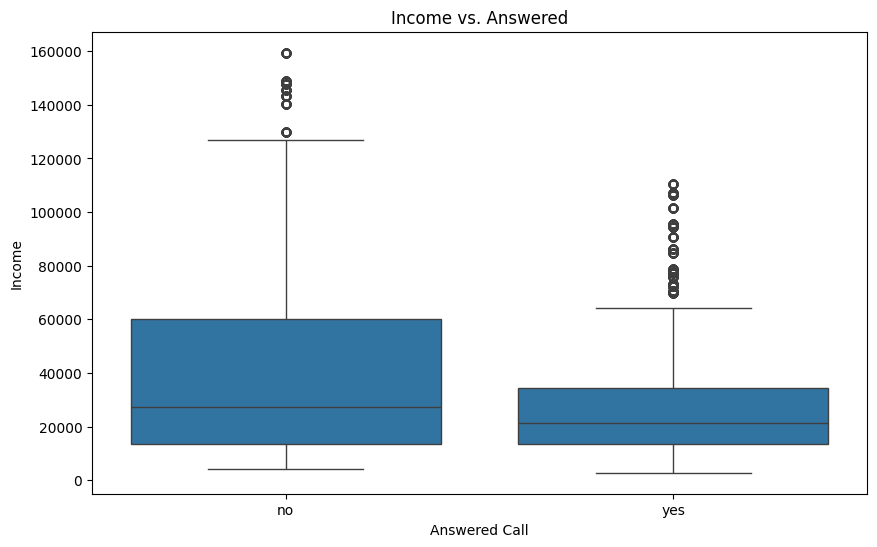

In [14]:
# Explore the relationship between 'answered' and 'income'
plt.figure(figsize=(10, 6))
sns.boxplot(x='answered', y='income', data=df_clean)
plt.title('Income vs. Answered')
plt.xlabel('Answered Call')
plt.ylabel('Income')
plt.show()

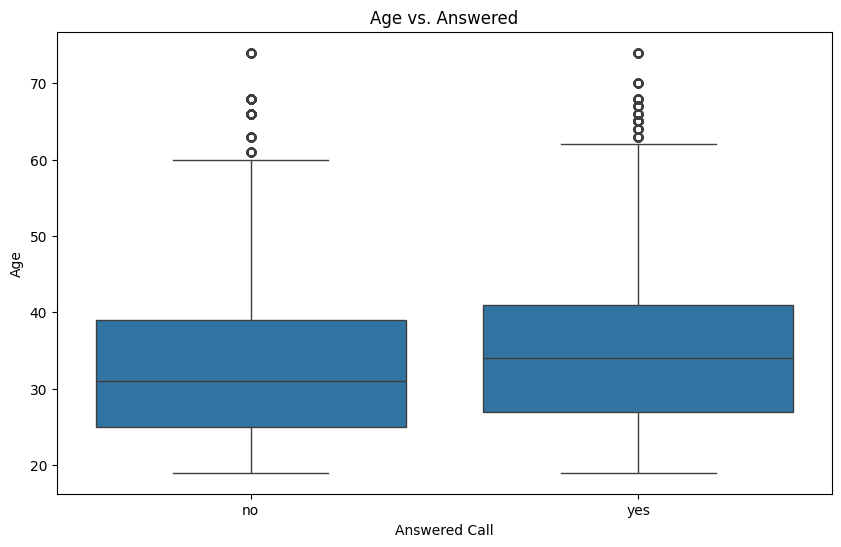

In [15]:
# Explore the relationship between 'answered' and 'age'
plt.figure(figsize=(10, 6))
sns.boxplot(x='answered', y='age', data=df_clean)
plt.title('Age vs. Answered')
plt.xlabel('Answered Call')
plt.ylabel('Age')
plt.show()

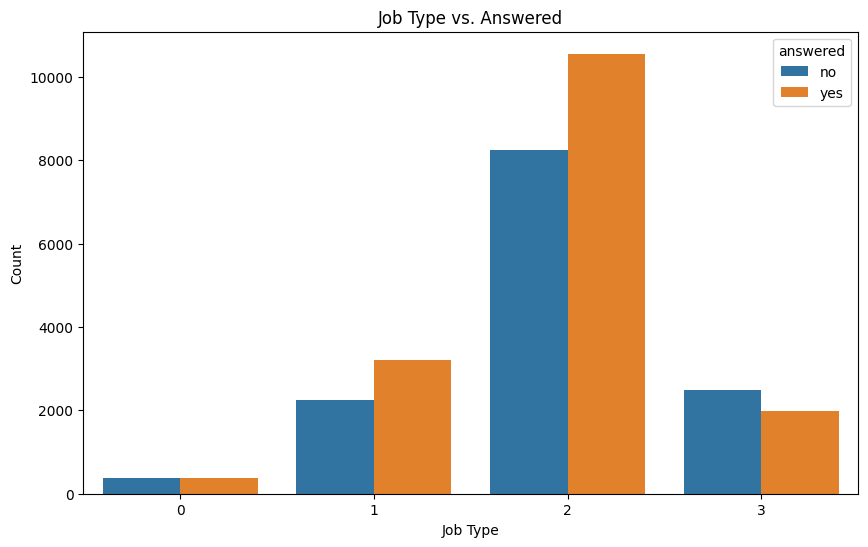

In [16]:
# Explore the relationship between 'answered' and 'job'
plt.figure(figsize=(10, 6))
sns.countplot(x='job', hue='answered', data=df_clean)
plt.title('Job Type vs. Answered')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.show()

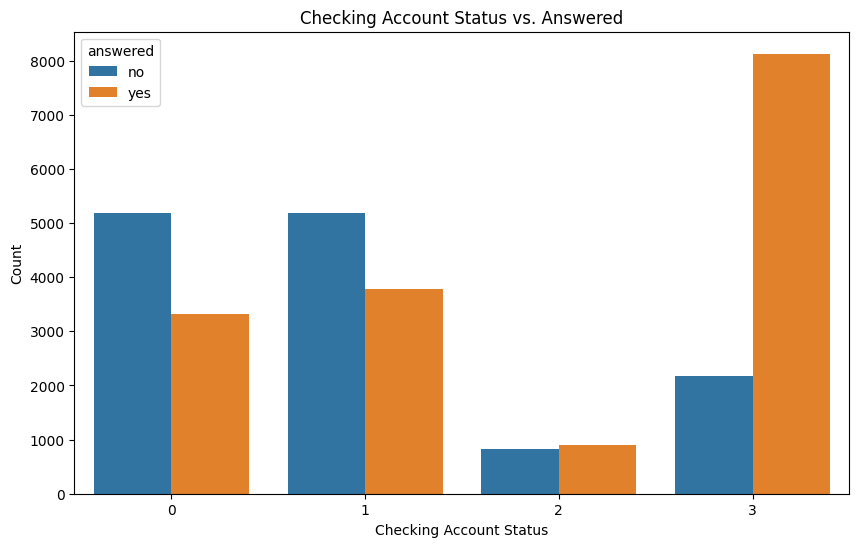

In [17]:
# Explore the relationship between 'answered' and 'chk_acct'
plt.figure(figsize=(10, 6))
sns.countplot(x='chk_acct', hue='answered', data=df_clean)
plt.title('Checking Account Status vs. Answered')
plt.xlabel('Checking Account Status')
plt.ylabel('Count')
plt.show()

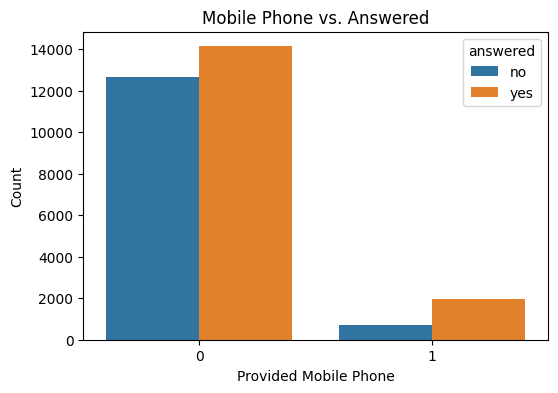

In [18]:
# Explore the relationship between 'answered' and 'mobile'
plt.figure(figsize=(6, 4))
sns.countplot(x='mobile', hue='answered', data=df_clean)
plt.title('Mobile Phone vs. Answered')
plt.xlabel('Provided Mobile Phone')
plt.ylabel('Count')
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [19]:
# Calculate the base probability of answering
base_probability_answered = df_clean['answered'].value_counts(normalize=True)['yes']
print(f"Base probability of answering: {base_probability_answered:.4f}")

Base probability of answering: 0.5467


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [21]:
# Split data into training and testing sets
X = df_clean.drop('answered', axis=1)
y = df_clean['answered']

# Convert categorical features to dummy variables
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [22]:
# Create a Decision Tree Classifier
# Use entropy as the criterion and set the max_depth to 4
decision_tree_model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

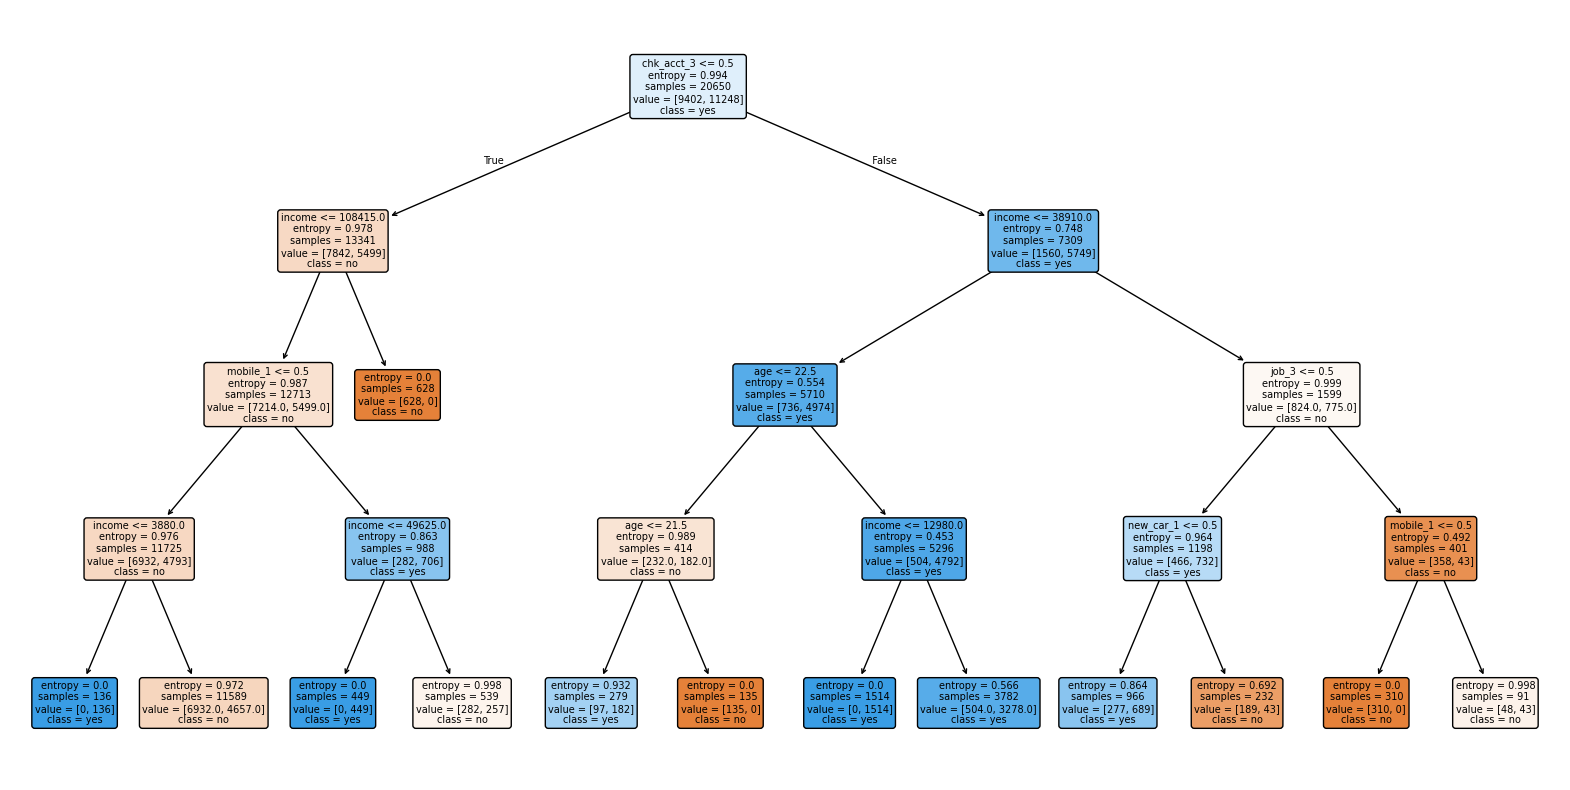

In [23]:
# display (visualize) the tree
plt.figure(figsize=(20, 10))
plot_tree(decision_tree_model, feature_names=X.columns, class_names=['no', 'yes'], filled=True, rounded=True)
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [24]:
# Calculate the accuracy of the model
y_pred = decision_tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree model: {accuracy:.4f}")

Accuracy of the Decision Tree model: 0.7024


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [25]:
#create a basic confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
display(conf_matrix)

Confusion Matrix:


array([[3634,  338],
       [2296, 2583]])

Create a more visual, interpretable version of the matrix

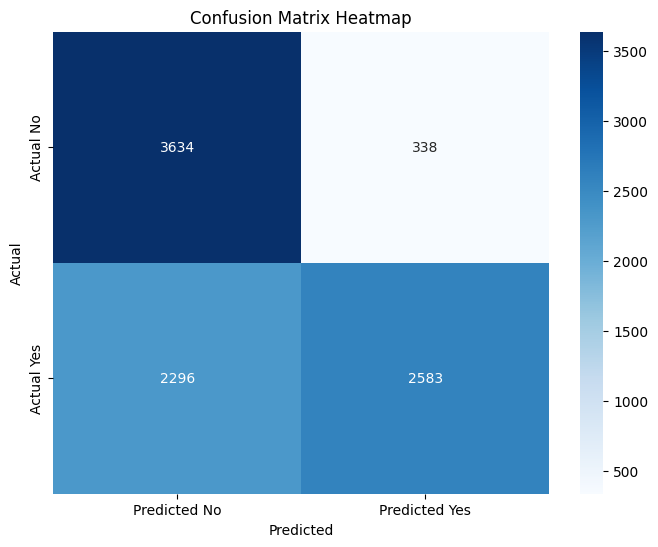

In [26]:
#Create a beautiful matrix; hint - try using Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [27]:
# Calculate the profit from your model
# True Positives (customer predicted to answer, does answer): conf_matrix[1, 1]
# False Positives (customer predicted to answer, does not answer): conf_matrix[0, 1]

true_positives = conf_matrix[1, 1]
false_positives = conf_matrix[0, 1]

# Profit = (True Positives * $75) - (False Positives * $25)
profit_with_model = (true_positives * 75) - (false_positives * 25)

print(f"Profit using the Decision Tree model: ${profit_with_model:.2f}")

Profit using the Decision Tree model: $185275.00


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [28]:
#Write a calculation for the overall profit without using the model (default)
# In this baseline scenario, all customers are called.
# True Positives are all customers who answered the call in the test set.
# False Positives are all customers who did not answer the call in the test set.

true_positives_default = y_test.value_counts()['yes']
false_positives_default = y_test.value_counts()['no']

# Profit = (True Positives * $75) - (False Positives * $25)
default_profit = (true_positives_default * 75) - (false_positives_default * 25)

print(f"Default profit (calling all customers): ${default_profit:.2f}")

Default profit (calling all customers): $266625.00


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [30]:
# Create a new version of the tree with new parameters
# Let's try increasing the max_depth to 6 to see if it improves accuracy.
decision_tree_model_tuned = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)

# Train the new model
decision_tree_model_tuned.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)

In [32]:
# Calculate the confusion matrix for the tuned model
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

# True Positives (customer predicted to answer, does answer): conf_matrix_tuned[1, 1]
# False Positives (customer predicted to answer, does not answer): conf_matrix_tuned[0, 1]

true_positives_tuned = conf_matrix_tuned[1, 1]
false_positives_tuned = conf_matrix_tuned[0, 1]

# Profit = (True Positives * $75) - (False Positives * $25)
profit_with_tuned_model = (true_positives_tuned * 75) - (false_positives_tuned * 25)

print(f"Profit using the tuned Decision Tree model: ${profit_with_tuned_model:.2f}")

# Compare with the initial model's profit
print(f"Profit using the initial Decision Tree model: ${profit_with_model:.2f}")

# Compare with the default profit
print(f"Default profit (calling all customers): ${default_profit:.2f}")

Profit using the tuned Decision Tree model: $207725.00
Profit using the initial Decision Tree model: $185275.00
Default profit (calling all customers): $266625.00


In [31]:
# Calculate the accuracy of the tuned model
y_pred_tuned = decision_tree_model_tuned.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy of the tuned Decision Tree model: {accuracy_tuned:.4f}")

# Compare with the initial model's accuracy
print(f"Accuracy of the initial Decision Tree model: {accuracy:.4f}")

Accuracy of the tuned Decision Tree model: 0.7467
Accuracy of the initial Decision Tree model: 0.7024


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [35]:
#Import new customer data into a new data frame
new_customer_df = pd.read_csv("adviseinvest_new_customer_data.csv")
display(new_customer_df.head())
display(new_customer_df.info())

,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   income          1000 non-null   int64 
 1   female          1000 non-null   int64 
 2   age             1000 non-null   int64 
 3   job             1000 non-null   int64 
 4   num_dependents  1000 non-null   int64 
 5   rent            1000 non-null   int64 
 6   own_res         1000 non-null   int64 
 7   new_car         1000 non-null   int64 
 8   chk_acct        1000 non-null   int64 
 9   sav_acct        1000 non-null   int64 
 10  num_accts       1000 non-null   int64 
 11  mobile          1000 non-null   int64 
 12  customer_id     1000 non-null   object
dtypes: int64(12), object(1)
memory usage: 101.7+ KB


None

In [37]:
# Prepare new customer data for prediction
# Drop the 'customer_id' column as it's not a feature
new_customer_df_processed = new_customer_df.drop('customer_id', axis=1)

# Convert categorical features to dummy variables, ensuring columns match training data
new_customer_df_processed = pd.get_dummies(new_customer_df_processed, drop_first=True)

# Align columns with the training data - add missing columns with default value 0
missing_cols = set(X_train.columns) - set(new_customer_df_processed.columns)
for c in missing_cols:
    new_customer_df_processed[c] = 0
# Ensure the order of columns is the same as in the training data
new_customer_df_processed = new_customer_df_processed[X_train.columns]


# Predict on the new data using the tuned model
new_customer_predictions = decision_tree_model_tuned.predict(new_customer_df_processed)

# Add predictions to the new customer dataframe
new_customer_df['predicted_answered'] = new_customer_predictions

# Count the number of 'yes' and 'no' predictions
prediction_counts = new_customer_df['predicted_answered'].value_counts()

print("Predicted number of customers who will answer (yes) and not answer (no):")
display(prediction_counts)

Predicted number of customers who will answer (yes) and not answer (no):


,count
predicted_answered,
no,994
yes,6


# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

We did not improve our profit using the model.

### 6.2: How could the model be utilized by the business?

The model could be utilized by the business for the prioritization of calls by predicting which customers are more likely to answer. It could also be used for resource allocation because by understanding which customers are more likely to answer, AdviseInvest could potentially allocate more sales representatives during peak times when the customers are scheduled.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [38]:
!jupyter nbconvert --to html "assignment_10_BensonDallin.ipynb"

[NbConvertApp] Converting notebook assignment_10_BensonDallin.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 832217 bytes to assignment_10_BensonDallin.html
